# Project Bayes — Wednesday Deep Analysis

Detail and follow-up views for the PSI eval. Use this notebook when someone asks *"but what about X?"* during the meeting.

For the headline view, see `wednesday_main.ipynb`. For 3 case walkthroughs, see `wednesday_examples.ipynb`.

## Setup

In [1]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 50)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

EVAL_DIR = Path("eval_output_psi")
df = pd.read_csv(EVAL_DIR / "per_case_scores.csv")
crit = pd.read_csv(EVAL_DIR / "criteria_long.csv")
done = df[df["error"].isna()].copy()
errored = df[df["error"].notna()].copy()

case_meta = pd.read_csv("eval_cases_psi.csv")
done = done.merge(
    case_meta[["ENCOUNTER_ID", "PSI_CODE", "PSI_TITLE", "LABEL", "CONFIDENCE",
               "PRIMARY_DX_CODE", "PRIMARY_DX_DESC", "AGE_INT", "GENDER"]].rename(
        columns={"ENCOUNTER_ID": "encounter_id"}
    ),
    on="encounter_id", how="left"
)
errored = errored.merge(
    case_meta[["ENCOUNTER_ID", "PSI_CODE", "LABEL"]].rename(
        columns={"ENCOUNTER_ID": "encounter_id"}
    ),
    on="encounter_id", how="left"
)

print(f"Loaded: {len(df)} task rows ({len(done)} clean, {len(errored)} errored)")


Loaded: 1441 task rows (1133 clean, 308 errored)


## 1. Per-PSI score distribution

Which of the 16 PSI categories do the models do best/worst on?

### Mean score per PSI

mut_model,claude-opus-4-7,gpt-5.5,n_cases
PSI_CODE,,,
PSI_19_OB_TRAUMA_NO_INSTRUMENT,0.613,0.661,6
PSI_15_ACCIDENTAL_PUNCTURE,0.580,0.586,15
PSI_14_WOUND_DEHISCENCE,0.498,0.475,9
PSI_18_OB_TRAUMA_INSTRUMENT,0.481,0.544,11
PSI_12_PERIOP_PE_DVT,0.474,0.515,5
PSI_06_IATROGENIC_PNEUMOTHORAX,0.473,0.480,13
PSI_09_POSTOP_HEMORRHAGE,0.469,0.504,15
PSI_08_FALL_FRACTURE,0.450,0.602,5
PSI_04_FAILURE_TO_RESCUE,0.426,0.386,8


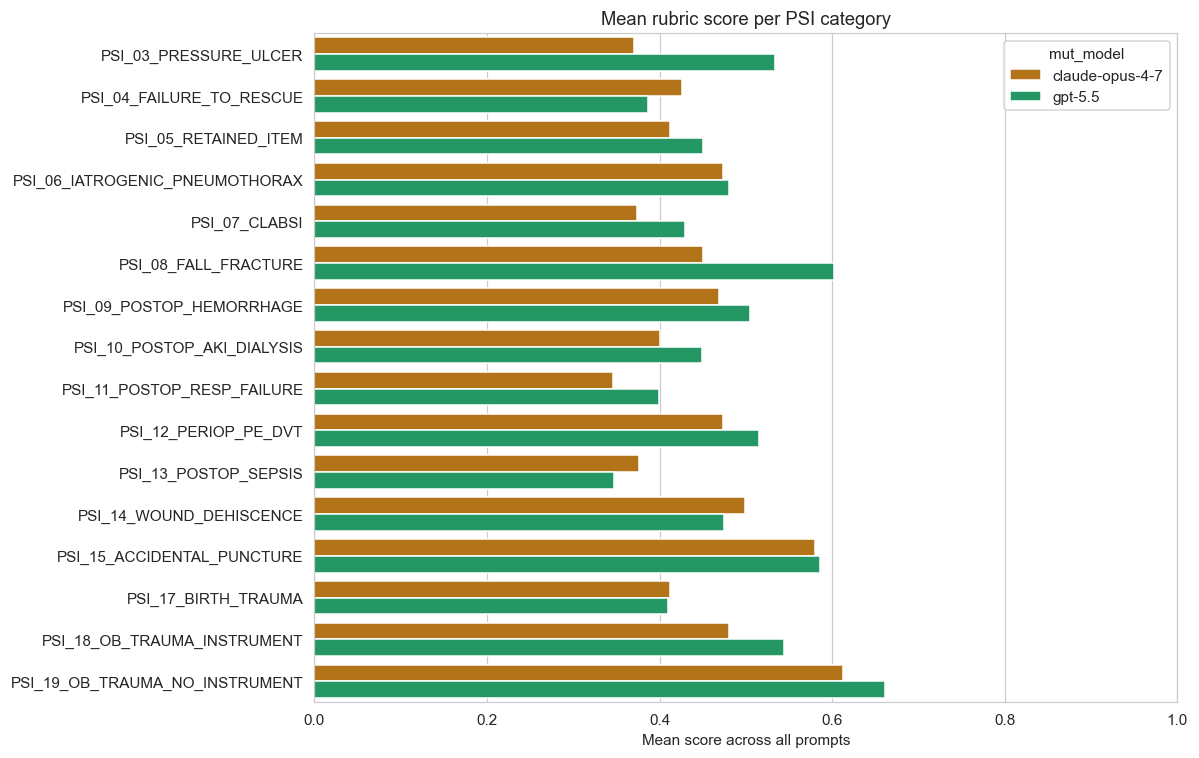

In [2]:
# Mean score per PSI × Model Under Testing
psi_pivot = done.pivot_table(
    index="PSI_CODE",
    columns="mut_model",
    values="score_mean",
    aggfunc="mean"
).round(3)
psi_pivot["n_cases"] = done.groupby("PSI_CODE")["encounter_id"].nunique()
psi_pivot = psi_pivot.sort_values("claude-opus-4-7", ascending=False)
display(Markdown("### Mean score per PSI"))
display(psi_pivot)

# Plot
fig, ax = plt.subplots(figsize=(11, 7))
melted = done.groupby(["PSI_CODE", "mut_model"])["score_mean"].mean().reset_index()
sns.barplot(data=melted, y="PSI_CODE", x="score_mean", hue="mut_model",
            palette={"claude-opus-4-7": "#cc7700", "gpt-5.5": "#11aa66"}, ax=ax)
ax.set_xlim(0, 1)
ax.set_title("Mean rubric score per PSI category")
ax.set_xlabel("Mean score across all prompts")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 2. Positive vs negative PSI cases

Does the model behave differently on cases where a PSI event actually happened vs. negative controls? If yes, the PSI label is leaking into the input somehow. If no, the rubric isn't picking up on PSI-relevance directly (expected for general-purpose prompts).

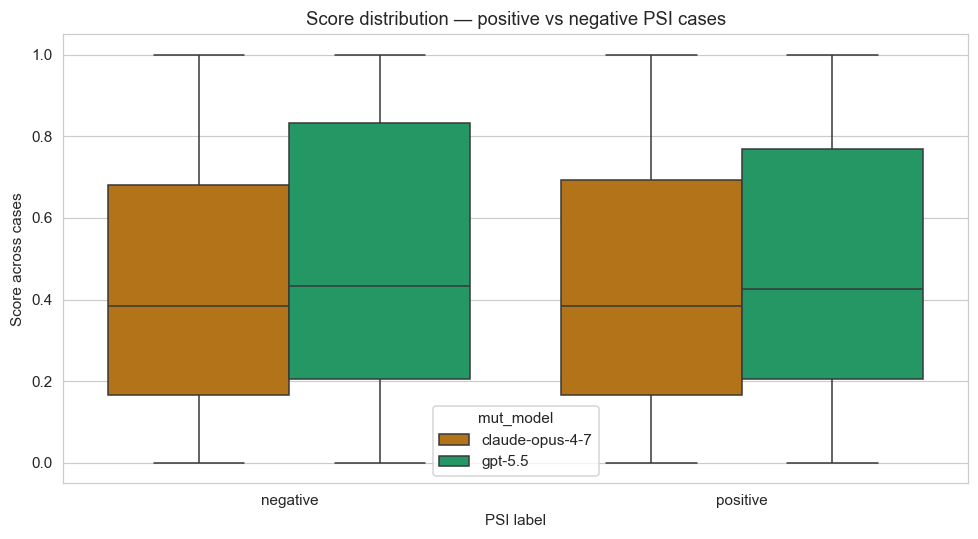

### Mean score: positive vs negative PSI cases

mut_model,claude-opus-4-7,gpt-5.5
LABEL,,
negative,0.453,0.480
positive,0.444,0.477


In [3]:
# Does the model score differently on positive vs negative PSI cases?
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=done, x="LABEL", y="score_mean", hue="mut_model",
            palette={"claude-opus-4-7": "#cc7700", "gpt-5.5": "#11aa66"}, ax=ax)
ax.set_title("Score distribution — positive vs negative PSI cases")
ax.set_xlabel("PSI label")
ax.set_ylabel("Score across cases")
plt.tight_layout()
plt.show()

display(Markdown("### Mean score: positive vs negative PSI cases"))
display(done.pivot_table(index="LABEL", columns="mut_model", values="score_mean", aggfunc="mean").round(3))


## 3. Per-prompt score histograms

Means hide the shape. Bimodal? Right-tailed? Useful for understanding rubric calibration.

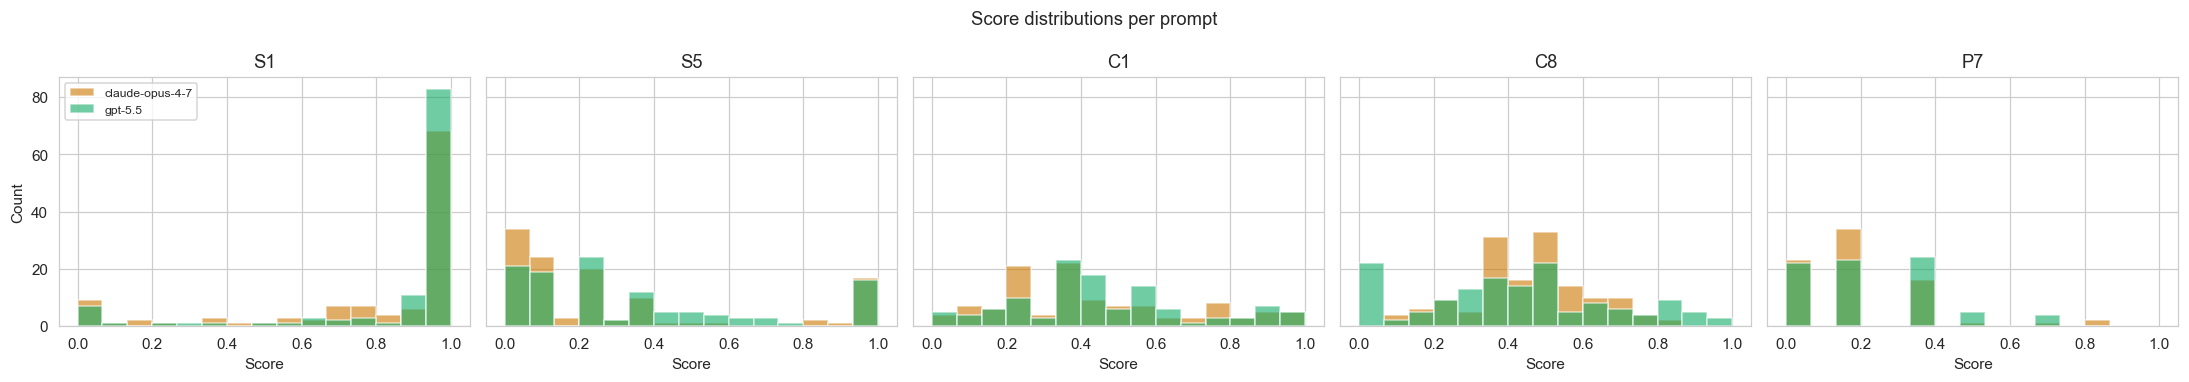

In [4]:
# Per-prompt score distribution (histograms, not just means)
prompts = ["S1", "S5", "C1", "C8", "P7"]
fig, axes = plt.subplots(1, len(prompts), figsize=(4 * len(prompts), 3.5), sharey=True)

for ax, pid in zip(axes, prompts):
    sub = done[done["prompt_id"] == pid]
    for mut, color in [("claude-opus-4-7", "#cc7700"), ("gpt-5.5", "#11aa66")]:
        s = sub[sub["mut_model"] == mut]["score_mean"]
        ax.hist(s, bins=15, range=(0, 1), alpha=0.6, label=mut, color=color)
    ax.set_title(pid)
    ax.set_xlabel("Score")
    if pid == "S1":
        ax.set_ylabel("Count")
        ax.legend(fontsize=8)
plt.suptitle("Score distributions per prompt")
plt.tight_layout()
plt.show()


## 4. Error / empty render investigation

Which cases fail completely (no prompts scored) and why?

In [5]:
# Error investigation
display(Markdown("### Error counts by prompt × Model Under Testing"))
display(errored.groupby(["prompt_id", "mut_model"]).size().unstack(fill_value=0))

display(Markdown("### Error types"))
display(errored["error"].value_counts())

display(Markdown("### Cases where ALL 5 prompts errored — these are renderer-incompatible cases"))
all_errored = errored.groupby("encounter_id")["prompt_id"].nunique()
fully_failed = all_errored[all_errored == 5].index
if len(fully_failed) > 0:
    display(case_meta[case_meta["ENCOUNTER_ID"].isin(fully_failed)][["ENCOUNTER_ID", "PSI_CODE", "LABEL", "PRIMARY_DX_CODE"]])
else:
    display(Markdown("_None — every case completed at least 1 prompt successfully._"))


### Error counts by prompt × Model Under Testing

mut_model,claude-opus-4-7,gpt-5.5
prompt_id,,
C1,29,29
P7,67,67
S1,29,29
S5,29,29


### Error types

error
empty render    308
Name: count, dtype: int64

### Cases where ALL 5 prompts errored — these are renderer-incompatible cases

_None — every case completed at least 1 prompt successfully._

## 5. Cost breakdown

In [6]:
# Cost breakdown
display(Markdown("### Total cost"))
print(f"Total LLM spend: ${done['total_cost_usd'].sum():.2f}")
print(f"  Model Under Testing portion: ${done['mut_cost_usd'].sum():.2f}")
print(f"  Judge portion: ${done['judge_cost_usd'].sum():.2f}")

display(Markdown("### Cost per (Model Under Testing × prompt)"))
cost_pivot = done.pivot_table(index="prompt_id", columns="mut_model",
                              values="total_cost_usd", aggfunc=["mean", "sum"]).round(3)
display(cost_pivot)


### Total cost

Total LLM spend: $243.67
  Model Under Testing portion: $135.42
  Judge portion: $108.25


### Cost per (Model Under Testing × prompt)

mean                     sum        
mut_model claude-opus-4-7 gpt-5.5 claude-opus-4-7 gpt-5.5
prompt_id                                                
C1                  0.127   0.114          14.469  13.042
C8                  0.612   0.446          88.112  64.165
P7                  0.180   0.153          13.855  11.968
S1                  0.067   0.061           7.718   7.094
S5                  0.106   0.095          12.298  10.948

## 6. Judge bias analysis

Does any one judge systematically score higher/lower than the others?

### Mean rubric score per judge (across all clean tasks)

,mean_score
score_sonnet,0.437
score_gpt_mini,0.339
score_gemini,0.615


### Per-judge mean by prompt

judge,score_gemini,score_gpt_mini,score_sonnet
prompt_id,,,
C1,0.70,0.26,0.38
C8,0.73,0.18,0.40
P7,0.33,0.07,0.20
S1,0.87,0.80,0.83
S5,0.32,0.34,0.31


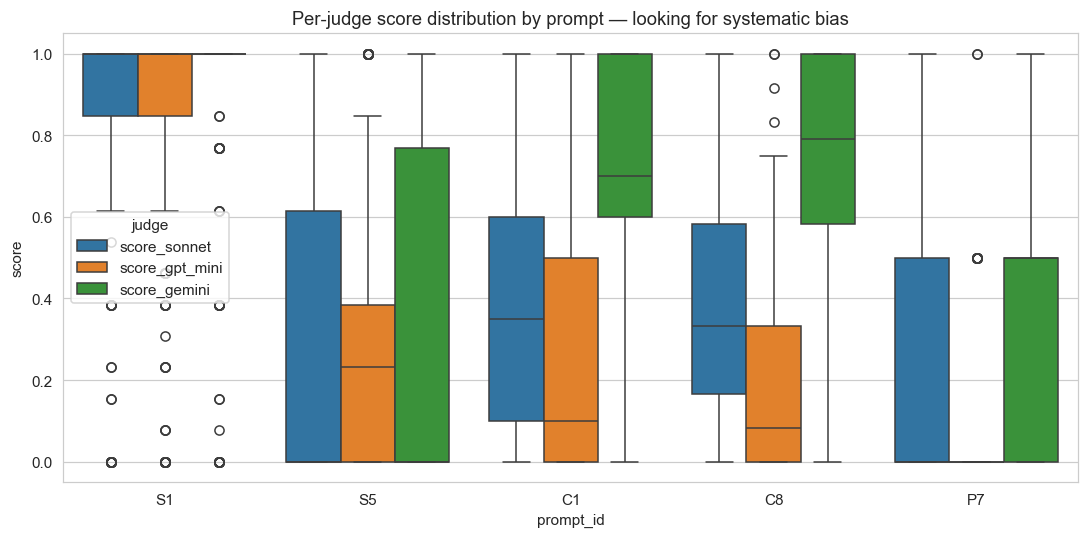

In [7]:
# Does each judge systematically score higher/lower?
judge_means = done[["score_sonnet", "score_gpt_mini", "score_gemini"]].mean().round(3)
display(Markdown("### Mean rubric score per judge (across all clean tasks)"))
display(judge_means.to_frame(name="mean_score"))

# Per-judge means by prompt
display(Markdown("### Per-judge mean by prompt"))
melt = done.melt(
    id_vars=["prompt_id", "mut_model"],
    value_vars=["score_sonnet", "score_gpt_mini", "score_gemini"],
    var_name="judge", value_name="score"
)
display(melt.pivot_table(index="prompt_id", columns="judge", values="score", aggfunc="mean").round(2))

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=melt, x="prompt_id", y="score", hue="judge", ax=ax,
            order=["S1", "S5", "C1", "C8", "P7"])
ax.set_title("Per-judge score distribution by prompt — looking for systematic bias")
plt.tight_layout()
plt.show()


## 7. Pairwise judge correlation

If judges' rankings of cases correlate strongly even when their absolute scores differ, the rubric is consistent (just scaled differently per judge). Low correlation means judges genuinely disagree about which cases are good vs bad.

### Pairwise correlation of judge scores

,score_sonnet,score_gpt_mini,score_gemini
score_sonnet,1.000,0.659,0.652
score_gpt_mini,0.659,1.000,0.481
score_gemini,0.652,0.481,1.000


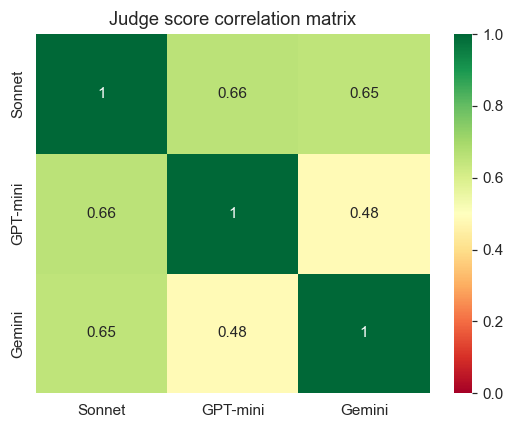

In [8]:
# Pairwise judge correlation (do judges agree on which cases are good vs bad?)
judge_cols = ["score_sonnet", "score_gpt_mini", "score_gemini"]
corr = done[judge_cols].corr().round(3)
display(Markdown("### Pairwise correlation of judge scores"))
display(corr)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, vmin=0, vmax=1, cmap="RdYlGn", ax=ax,
            xticklabels=["Sonnet", "GPT-mini", "Gemini"],
            yticklabels=["Sonnet", "GPT-mini", "Gemini"])
ax.set_title("Judge score correlation matrix")
plt.tight_layout()
plt.show()


## 8. Look-ahead bias audit

In [9]:
# Look-ahead bias audit summary
display(Markdown("""### Leakage audit

Renderer applies these protections by design (see `DATA_QUALITY_ISSUES.md` for full inventory):

| Protection | Affects |
|---|---|
| Sentinel-date filter (NOTE_DATE before EN_START_DATE) | All time-truncated prompts (P7 here) |
| Discharge-note exclusion (NOTE_TYPE matches DISCHARGE/DEATH/EXPIRED) | All time-truncated prompts |
| Narrative A&P redaction in ATTENDING COMMENTS | P1, P2 (not in this run) |
| Auto-drop diagnoses table for P3/P4 | P3, P4 (not in this run) |
| Multi-supplier dedupe (row-level + line-level) | All prompts |
| Sentinel-date GT extension (include for ground truth, exclude from input) | P10 (not in this run) |

For this PSI run, the most-active protections are sentinel-date filter and discharge-note exclusion (both apply to P7).
S1/S5/C1 are single-note prompts so leakage risk is local to the note section structure."""))


### Leakage audit

Renderer applies these protections by design (see `DATA_QUALITY_ISSUES.md` for full inventory):

| Protection | Affects |
|---|---|
| Sentinel-date filter (NOTE_DATE before EN_START_DATE) | All time-truncated prompts (P7 here) |
| Discharge-note exclusion (NOTE_TYPE matches DISCHARGE/DEATH/EXPIRED) | All time-truncated prompts |
| Narrative A&P redaction in ATTENDING COMMENTS | P1, P2 (not in this run) |
| Auto-drop diagnoses table for P3/P4 | P3, P4 (not in this run) |
| Multi-supplier dedupe (row-level + line-level) | All prompts |
| Sentinel-date GT extension (include for ground truth, exclude from input) | P10 (not in this run) |

For this PSI run, the most-active protections are sentinel-date filter and discharge-note exclusion (both apply to P7).
S1/S5/C1 are single-note prompts so leakage risk is local to the note section structure.

## 9. Cases flagged for human review

Sorted by maximum pairwise judge disagreement. These are the cases where independent reviewers (a real clinician) would be most valuable.

In [10]:
# Cases flagged for human review — highest judge disagreement
display(Markdown("### Top 20 cases with highest judge disagreement (delta_max ≥ 0.5)"))
flagged = done[done["judge_delta_max"] >= 0.5].copy()
flagged = flagged.sort_values("judge_delta_max", ascending=False).head(20)
display(flagged[[
    "encounter_id", "prompt_id", "mut_model", "PSI_CODE", "LABEL",
    "score_sonnet", "score_gpt_mini", "score_gemini",
    "judge_delta_max", "model_response_excerpt"
]].round(2))

print(f"\nTotal cases with delta ≥ 0.5: {(done['judge_delta_max'] >= 0.5).sum()} / {len(done)}")
print(f"Total cases with delta ≥ 0.3: {(done['judge_delta_max'] >= 0.3).sum()} / {len(done)}")


### Top 20 cases with highest judge disagreement (delta_max ≥ 0.5)

,encounter_id,prompt_id,mut_model,PSI_CODE,LABEL,score_sonnet,score_gpt_mini,score_gemini,judge_delta_max,model_response_excerpt
0,DA815B68-4F8E-4E0C-9E39-7205C115223D,S1,claude-opus-4-7,PSI_03_PRESSURE_ULCER,negative,1.00,1.00,0.0,1.0,"Wound Check, sacral wound"
283,3706AB14-1AFD-44E3-B172-6EA12EE12677,C1,gpt-5.5,PSI_06_IATROGENIC_PNEUMOTHORAX,negative,0.10,0.00,1.0,1.0,"**Admission H&P Date: 03/20/2022**\n\n- **Multiple hemorrhagic brain metastases from recently diagnosed poorly differentiated adenocarcinoma (primary unclear: lung vs hepatobiliary), complicated by intraventricular hemorrhage, vasogenic edema, brain compression, obstructive hydrocephalus, and encephalopathy**\n - CT on 3/19 showed marked expansion of right frontal hemorrhagic metastasis with large I"
709,53FB2D3C-95F6-46A7-9AE2-9CF7CFBD8420,C8,claude-opus-4-7,PSI_11_POSTOP_RESP_FAILURE,positive,0.33,0.00,1.0,1.0,"# Lab Results Summary\n\n## Abnormal Values & Recommended Clinical Actions\n\n### Coagulation\n| Test | Value | Reference | Action |\n|------|-------|-----------|--------|\n| **PT** | 17.4 sec (peak), 16.4 sec | 12.0–15.0 | Evaluate for liver dysfunction (consistent with hepatic injury seen here); hold anticoagulation given concurrent GI bleed; consider vitamin K if persistently elevated. |\n| **INR** | 1"
716,B066A479-22C1-4F31-81BB-4C5A57202FE0,P7,gpt-5.5,PSI_11_POSTOP_RESP_FAILURE,positive,0.00,0.00,1.0,1.0,Predicted next routine inpatient lab panel (likely next AM CBC/CMP):\n\n| Lab | Predicted value | Units | Expected flag |\n|---|---:|---|---|\n| WBC | 8.4 | K/uL | Within reference |\n| RBC | 4.25 | M/uL | Low |\n| Hemoglobin | 13.3 | g/dL | Low |\n| Hematocrit | 39.5 | % | Low |\n| MCV | 93 | fL | Within reference |\n| MCH | 31.3 | pg | High |\n| MCHC | 33.7 | g/dL | Within reference |\n| RDW | 15.6 | % | H
720,B066A479-22C1-4F31-81BB-4C5A57202FE0,C8,gpt-5.5,PSI_11_POSTOP_RESP_FAILURE,positive,0.42,0.00,1.0,1.0,"### Overall lab summary\nLabs show **ongoing infection/inflammation**, **acute blood loss anemia**, **acute kidney injury**, **electrolyte abnormalities**, **malnutrition**, and **respiratory failure/CHF physiology** during the admission for severe right foot infection/PVD requiring revascularization and 5th toe amputation.\n\n### Abnormal results and appropriate actions/follow-up\n\n| Abnormal result"
257,63C2C13D-F890-4EF2-A602-5ED0032A3FCB,C8,claude-opus-4-7,PSI_06_IATROGENIC_PNEUMOTHORAX,negative,0.42,0.00,1.0,1.0,# Lab Results Summary\n\n**No laboratory results are available in the provided clinical record for this encounter.**\n\nThe record documents a same-day (0-day LOS) admission on 2017-11-29 for a bronchoscopy with electromagnetic navigational guidance and endobronchial ultrasound-guided placement of fiducial markers for planned stereotactic/CyberKnife radiation therapy of a peripheral right upper lobe m
252,63C2C13D-F890-4EF2-A602-5ED0032A3FCB,C1,gpt-5.5,PSI_06_IATROGENIC_PNEUMOTHORAX,negative,0.60,0.00,1.0,1.0,**Date of note:** 2017-11-29\n\nNo admission H&P Assessment and Plan is provided in the text. The only note states that Dr. Jones was notified by Dr. Bains that fiducial markers had been placed. No problems or management plans are documented in this note.
722,D95F14B3-0F8B-4B54-83C1-FE279F6F5DA2,C1,claude-opus-4-7,PSI_12_PERIOP_PE_DVT,negative,0.60,0.00,1.0,1.0,"# Assessment and Plan Summary — H&P Note dated 2022-03-16\n\n**Patient:** Margaret Araya, 50yo F admitted to observation status\n\n## Problems and Plans:\n\n1. **Acute on chronic back pain, unable to ambulate** — Pain control; increase mobility as possible\n2. **Progressive low back pain** (no bladder/bowel involvement) — PT/OT\n3. **Super morbid obesity** (BMI 58.78) — Supportive\n4. **Type 2 Diabetes** —"
736,64C33E54-550A-41E1-AA92-F6ABA9F2DB7D,C1,gpt-5.5,PSI_12_PERIOP_PE_DVT,negative,0.00,0.00,1.0,1.0,"**Date of note: 2017-09-08**\n\n### Assessment & Plan\n- **Bilateral heel diabetic/pressure/arterial insufficiency ulcers, Mueller/Wagner grade 4**\n - Wou


Total cases with delta ≥ 0.5: 518 / 1133
Total cases with delta ≥ 0.3: 703 / 1133
